# Exercícios — Estatística Bayesiana

**Tema:** Estatística › Estatística Bayesiana

O teste destes exercícios não é "você sabe a fórmula de Bayes?", e sim
**você consegue transformar uma pergunta de negócio em uma posteriori, e a
posteriori numa decisão?**

1. **Enunciado** → 2. **Célula de resposta** → 3. **Gabarito comentado**.

**Dificuldade:** 🟢 base · 🟡 aplicação · 🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(2718)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"


def painel(titulo, **metricas):
    print(titulo)
    print("-" * max(len(titulo), 50))
    for nome, valor in metricas.items():
        rotulo = nome.replace("_", " ")
        print(f"{rotulo:<36s} {valor:>12.5f}" if isinstance(valor, (int, float, np.floating))
              else f"{rotulo:<36s} {valor:>12}")
    print()


print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — Taxa-base em um detector de fraude

Seu modelo de fraude tem **recall de 95%** e **taxa de falso positivo de 2%**.
A base tem 0,3% de transações fraudulentas.

1. Qual a probabilidade de uma transação sinalizada ser realmente fraude?
2. Quantos alarmes falsos por fraude verdadeira o time de análise recebe?
3. Qual taxa de falso positivo seria necessária para que metade dos alarmes
   fosse fraude real?

In [2]:
# --- sua resposta ---

### Gabarito 1

Detector de fraude
--------------------------------------------------
prevalencia                               0.00300
recall                                    0.95000
taxa falso positivo                       0.02000
P fraude dado alarme                      0.12505
alarmes falsos por fraude                 6.99649

Para precisão de 50%, a TFP teria que cair para 0.00286 (14.3% da atual).



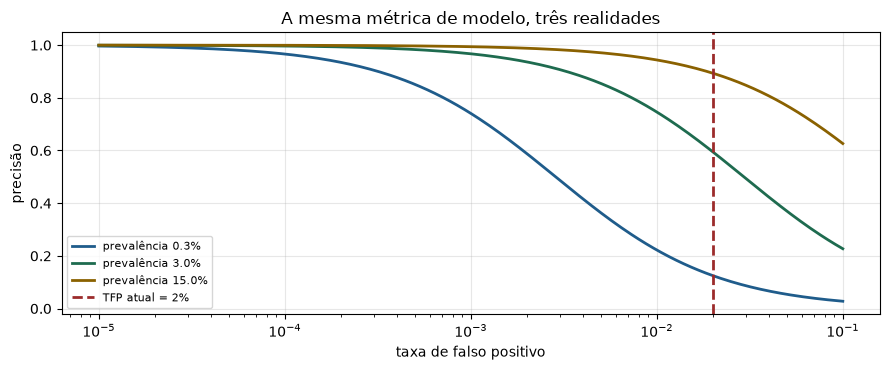

In [3]:
PREVALENCIA, RECALL, TFP = 0.003, 0.95, 0.02


def precisao(prevalencia, recall, tfp):
    vp = prevalencia * recall
    fp = (1 - prevalencia) * tfp
    return vp / (vp + fp)


prec = precisao(PREVALENCIA, RECALL, TFP)
painel("Detector de fraude",
       prevalencia=PREVALENCIA, recall=RECALL, taxa_falso_positivo=TFP,
       P_fraude_dado_alarme=prec,
       alarmes_falsos_por_fraude=(1 - prec) / prec)

# qual TFP daria precisão de 50%?
tfp_alvo = PREVALENCIA * RECALL / (1 - PREVALENCIA)
print(f"Para precisão de 50%, a TFP teria que cair para {tfp_alvo:.5f} "
      f"({tfp_alvo/TFP:.1%} da atual).\n")

grade_tfp = np.logspace(-5, -1, 300)
fig, ax = plt.subplots(figsize=(9, 3.8))
for prev, cor in [(0.003, AZUL), (0.03, VERDE), (0.15, AMBAR)]:
    ax.plot(grade_tfp, precisao(prev, RECALL, grade_tfp), lw=2, color=cor,
            label=f"prevalência {prev:.1%}")
ax.axvline(TFP, color=VERMELHO, ls="--", lw=2, label="TFP atual = 2%")
ax.set_xscale("log"); ax.set_xlabel("taxa de falso positivo"); ax.set_ylabel("precisão")
ax.set_title("A mesma métrica de modelo, três realidades")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**~12,5% de precisão:** cerca de **7 alarmes falsos para cada fraude real**. O
modelo tem métricas excelentes e a operação é inviável — analistas descartam
7 casos legítimos antes de achar um verdadeiro, e em pouco tempo param de
olhar com atenção.

**O que a curva mostra:** para eventos raros, a precisão é governada pela taxa
de falso positivo, não pelo recall. Ganhar 3 pontos de recall não muda nada;
derrubar a TFP de 2% para 0,3% muda tudo.

**Consequência de projeto:** em classe muito desbalanceada, otimize o limiar
por **precisão a um recall aceitável** (ou por custo esperado), nunca por
acurácia — e reporte a curva **PR**, não a ROC, que fica otimista demais.

---
## Exercício 2 🟢 — Beta-Binomial na mão

Uma nova landing page teve **9 conversões em 60 visitas**. O histórico da
empresa é de conversão em torno de 8%.

1. Escolha uma priori Beta que codifique o histórico e justifique os números.
2. Calcule a posteriori e o intervalo de credibilidade 95%.
3. Compare com a estimativa clássica (9/60).
4. Repita com priori uniforme e com priori muito forte. O que muda?

In [4]:
# --- sua resposta ---

### Gabarito 2

                                     priori  média post.  IC inf  IC sup  largura
                         uniforme Beta(1,1)       0.1613  0.0815  0.2617   0.1802
    fraca Beta(4,46) — ~8%, vale 50 visitas       0.1182  0.0651  0.1844   0.1194
forte Beta(80,920) — ~8%, vale 1000 visitas       0.0840  0.0680  0.1014   0.0333

estimativa clássica (MLE): 0.1500
IC 95% clássico (Wilson):  ConfidenceInterval(low=np.float64(0.07095619525709114), high=np.float64(0.2657404477572951))


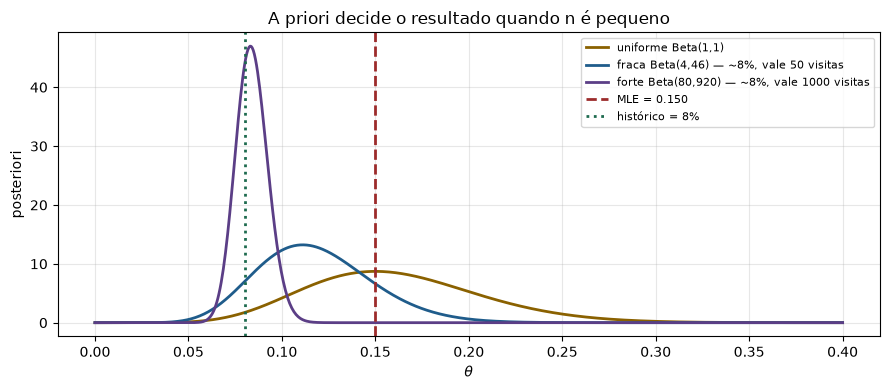

In [5]:
N, K = 60, 9

prioris = {
    "uniforme Beta(1,1)": (1, 1),
    "fraca Beta(4,46) — ~8%, vale 50 visitas": (4, 46),
    "forte Beta(80,920) — ~8%, vale 1000 visitas": (80, 920),
}

linhas = []
for nome, (a, b) in prioris.items():
    post = stats.beta(a + K, b + N - K)
    ic = post.ppf([0.025, 0.975])
    linhas.append({"priori": nome, "média post.": post.mean(),
                   "IC inf": ic[0], "IC sup": ic[1],
                   "largura": ic[1] - ic[0]})
print(pd.DataFrame(linhas).round(4).to_string(index=False))
print(f"\nestimativa clássica (MLE): {K/N:.4f}")
print(f"IC 95% clássico (Wilson):  {stats.binomtest(K, N).proportion_ci(0.95)}")

fig, ax = plt.subplots(figsize=(9, 4))
g = np.linspace(0, 0.4, 700)
for (nome, (a, b)), cor in zip(prioris.items(), [AMBAR, AZUL, ROXO]):
    ax.plot(g, stats.beta.pdf(g, a + K, b + N - K), lw=2, color=cor, label=nome)
ax.axvline(K / N, color=VERMELHO, lw=2, ls="--", label=f"MLE = {K/N:.3f}")
ax.axvline(0.08, color=VERDE, lw=2, ls=":", label="histórico = 8%")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("posteriori")
ax.set_title("A priori decide o resultado quando n é pequeno")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**Como escolher os números da priori:** $\alpha + \beta$ é o "peso" da priori
em pseudo-observações. Beta(4, 46) diz "eu já vi o equivalente a 50 visitas com
8% de conversão" — informação real, mas facilmente superada por 60 visitas
novas. Beta(80, 920) vale 1.000 visitas e engole a amostra.

**A regra prática:** escolha $\alpha + \beta$ igual ao número de observações
que sua convicção realmente vale. Se o histórico vem de 200 mil visitas mas o
contexto mudou (novo público, nova sazonalidade), ele não vale 200 mil — vale
talvez algumas centenas.

**Sempre faça análise de sensibilidade.** Rodar as três prioris e mostrar a
tabela é o que transforma "escolha subjetiva" em "escolha declarada e
auditável". Se a conclusão muda entre prioris razoáveis, você não tem dado
suficiente para concluir — e isso também é um resultado.

---
## Exercício 3 🟡 — A/B test bayesiano completo

Controle: 1.180 conversões em 12.400 visitas. Tratamento: 1.290 em 12.350.

Produza o laudo que um time de produto usa:

1. $P(B > A)$;
2. posteriori do **lift relativo** com IC 95%;
3. **perda esperada** de escolher cada variante;
4. $P(\text{lift} > 3\%)$ — o mínimo que justifica o custo de implantação;
5. uma recomendação em uma frase.

In [6]:
# --- sua resposta ---

### Gabarito 3

A/B test bayesiano
--------------------------------------------------
conversao A                               0.09516
conversao B                               0.10445
P B melhor que A                          0.99240
lift mediano                              0.09755
lift IC inf                               0.01820
lift IC sup                               0.18292
P lift acima de 3pct                      0.95157
perda esperada escolhendo B               0.00001
perda esperada escolhendo A               0.00930



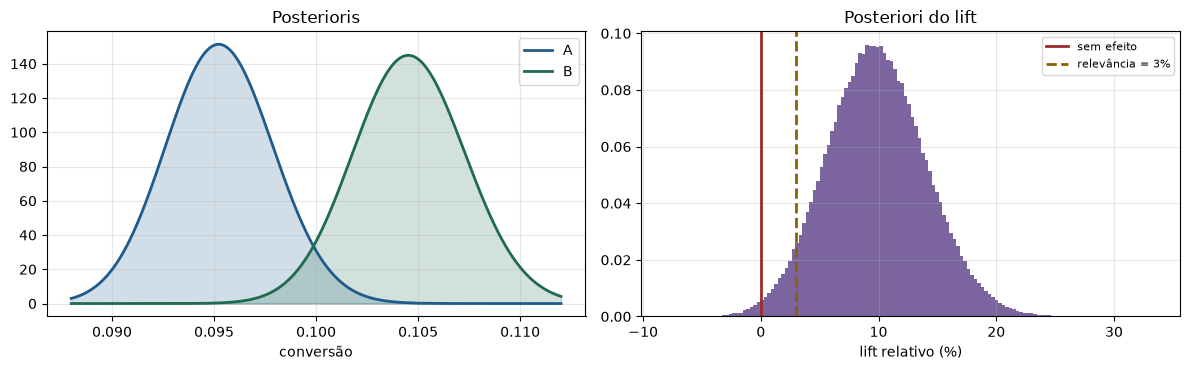

RECOMENDAÇÃO: implantar B. P(B>A) = 99.2% e a perda esperada de
fazê-lo é 0.000009 conversões/visita — cerca de 0.9 conversões a cada 100 mil visitas, no pior caso médio.
Ressalva: P(lift > 3%) = 95.2%, então o ganho
provavelmente é REAL mas MODESTO — dimensione o esforço de implantação por isso.


In [7]:
n_a, k_a = 12_400, 1_180
n_b, k_b = 12_350, 1_290
A0, B0 = 2, 2                    # priori fracamente regularizadora
LIMIAR_RELEVANCIA = 0.03

post_a = stats.beta(A0 + k_a, B0 + n_a - k_a)
post_b = stats.beta(A0 + k_b, B0 + n_b - k_b)

M = 400_000
sa, sb = post_a.rvs(M, random_state=10), post_b.rvs(M, random_state=11)
lift = sb / sa - 1

p_b_melhor = (sb > sa).mean()
perda_b = np.maximum(sa - sb, 0).mean()
perda_a = np.maximum(sb - sa, 0).mean()

painel("A/B test bayesiano",
       conversao_A=k_a / n_a, conversao_B=k_b / n_b,
       P_B_melhor_que_A=p_b_melhor,
       lift_mediano=np.median(lift),
       lift_IC_inf=np.percentile(lift, 2.5), lift_IC_sup=np.percentile(lift, 97.5),
       P_lift_acima_de_3pct=(lift > LIMIAR_RELEVANCIA).mean(),
       perda_esperada_escolhendo_B=perda_b,
       perda_esperada_escolhendo_A=perda_a)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
g = np.linspace(0.088, 0.112, 700)
axes[0].plot(g, post_a.pdf(g), color=AZUL, lw=2, label="A")
axes[0].plot(g, post_b.pdf(g), color=VERDE, lw=2, label="B")
axes[0].fill_between(g, post_a.pdf(g), color=AZUL, alpha=0.2)
axes[0].fill_between(g, post_b.pdf(g), color=VERDE, alpha=0.2)
axes[0].set_xlabel("conversão"); axes[0].legend(); axes[0].set_title("Posterioris")

axes[1].hist(lift * 100, bins=140, density=True, color=ROXO, alpha=0.8)
axes[1].axvline(0, color=VERMELHO, lw=2, label="sem efeito")
axes[1].axvline(LIMIAR_RELEVANCIA * 100, color=AMBAR, lw=2, ls="--",
                label="relevância = 3%")
axes[1].set_xlabel("lift relativo (%)"); axes[1].legend(fontsize=8)
axes[1].set_title("Posteriori do lift")
plt.tight_layout(); plt.show()

print(f"RECOMENDAÇÃO: implantar B. P(B>A) = {p_b_melhor:.1%} e a perda esperada de")
print(f"fazê-lo é {perda_b:.6f} conversões/visita — cerca de "
      f"{perda_b * 100_000:.1f} conversões a cada 100 mil visitas, no pior caso médio.")
print(f"Ressalva: P(lift > 3%) = {(lift > LIMIAR_RELEVANCIA).mean():.1%}, então o ganho")
print("provavelmente é REAL mas MODESTO — dimensione o esforço de implantação por isso.")

**O que faz esse laudo ser útil:**

- **$P(B>A)$** responde a pergunta que foi feita, sem intermediários.
- **A perda esperada** é a métrica de decisão: quanto custa, em conversões, se
  eu escolher B e estiver errado. Times maduros definem um limiar de tolerância
  e param o teste quando a perda esperada cai abaixo dele.
- **$P(\text{lift} > 3\%)$** separa "existe efeito" de "vale a pena" — que é a
  pergunta que o frequentista não responde sem contorcionismo.

> **Cuidado com a interpretação de $P(B>A) = 96\%$:** isso é probabilidade de
> B ser **melhor**, não de o lift ser **grande**. Com amostra enorme, você pode
> ter 99,9% de certeza de um lift de 0,3% — certeza altíssima sobre algo
> irrelevante.

---
## Exercício 4 🟡 — Gama-Poisson e a distribuição preditiva

Você opera um call center. Nos últimos 10 dias: `[19, 24, 22, 31, 18, 27, 25, 20, 29, 23]`
chamados por dia. O histórico do ano passado indica ~21/dia.

1. Monte a priori Gama e calcule a posteriori de $\lambda$.
2. Calcule a **distribuição preditiva** para amanhã.
3. Quantos atendentes escalar para cobrir 95% dos dias (cada um atende 6/dia)?
4. Compare com o dimensionamento feito pela média. Qual a diferença de risco?

In [8]:
# --- sua resposta ---

### Gabarito 4

Call center
--------------------------------------------------
media observada                          23.80000
lambda posterior medio                   23.54545
lambda IC inf                            20.76499
lambda IC sup                            26.49808
preditiva media                          23.54291
preditiva p95                            32.00000
atendentes pela media                     4.00000
atendentes pelo p95                       6.00000

P(estourar a capacidade com 4 atendentes) = 41.1%
P(estourar a capacidade com 6 atendentes) = 0.9%


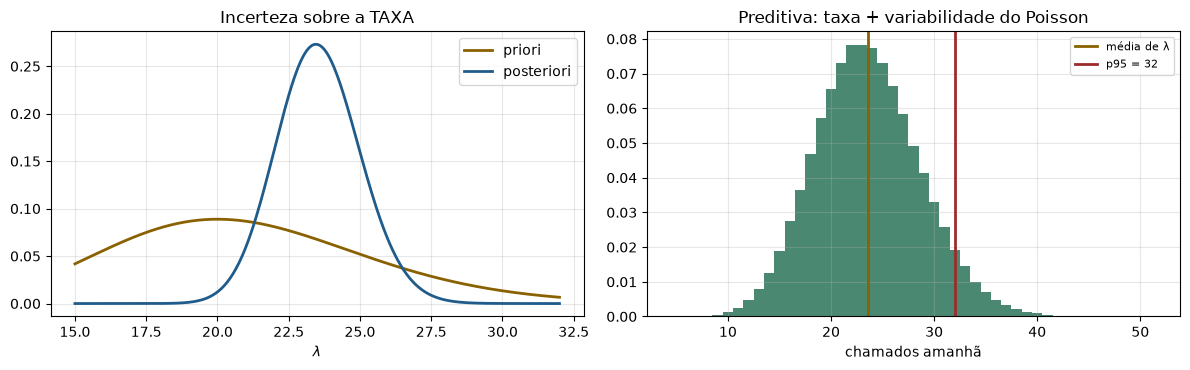

In [9]:
chamados = np.array([19, 24, 22, 31, 18, 27, 25, 20, 29, 23])
ALFA0, BETA0 = 21, 1          # "vi 21 chamados em 1 dia" — priori fraca centrada no histórico
CAPACIDADE = 6

alfa_post = ALFA0 + chamados.sum()
beta_post = BETA0 + len(chamados)
post = stats.gamma(a=alfa_post, scale=1 / beta_post)

lambdas = post.rvs(400_000, random_state=21)
preditiva = rng.poisson(lambdas)

p95 = np.percentile(preditiva, 95)
painel("Call center",
       media_observada=chamados.mean(),
       lambda_posterior_medio=post.mean(),
       lambda_IC_inf=post.ppf(0.025), lambda_IC_sup=post.ppf(0.975),
       preditiva_media=preditiva.mean(), preditiva_p95=p95,
       atendentes_pela_media=np.ceil(post.mean() / CAPACIDADE),
       atendentes_pelo_p95=np.ceil(p95 / CAPACIDADE))

eq_media = np.ceil(post.mean() / CAPACIDADE)
eq_p95 = np.ceil(p95 / CAPACIDADE)
print(f"P(estourar a capacidade com {eq_media:.0f} atendentes) = "
      f"{(preditiva > eq_media * CAPACIDADE).mean():.1%}")
print(f"P(estourar a capacidade com {eq_p95:.0f} atendentes) = "
      f"{(preditiva > eq_p95 * CAPACIDADE).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
g = np.linspace(15, 32, 500)
axes[0].plot(g, stats.gamma.pdf(g, a=ALFA0, scale=1 / BETA0), color=AMBAR, lw=2,
             label="priori")
axes[0].plot(g, post.pdf(g), color=AZUL, lw=2, label="posteriori")
axes[0].set_xlabel(r"$\lambda$"); axes[0].legend()
axes[0].set_title("Incerteza sobre a TAXA")

bins = np.arange(preditiva.min(), preditiva.max() + 2) - 0.5
axes[1].hist(preditiva, bins=bins, density=True, color=VERDE, alpha=0.8)
axes[1].axvline(post.mean(), color=AMBAR, lw=2, label="média de λ")
axes[1].axvline(p95, color=VERMELHO, lw=2, label=f"p95 = {p95:.0f}")
axes[1].set_xlabel("chamados amanhã"); axes[1].legend(fontsize=8)
axes[1].set_title("Preditiva: taxa + variabilidade do Poisson")
plt.tight_layout(); plt.show()

**A diferença que importa:** a posteriori de $\lambda$ é estreita (a incerteza
sobre a *taxa* é pequena com 10 dias de dados). A **preditiva** é muito mais
larga, porque soma a variabilidade intrínseca do Poisson — em um dia com
$\lambda = 24$, o número real ainda oscila de 15 a 34.

**Dimensionar pela média deixa a operação estourando em quase metade dos
dias.** Dimensionar pelo p95 da preditiva reduz isso para ~5%, ao custo de um
atendente a mais. Essa é a conversa de custo × nível de serviço, e ela só é
possível com a preditiva na mão.

> **O erro de esquecer a preditiva** é o mesmo que reportar "a previsão de
> vendas é 1.200 unidades" sem intervalo. Estoque, plantão e capacidade se
> dimensionam por **quantis**, nunca por médias.

---
## Exercício 5 🟡 — Credibilidade × confiança, medidos lado a lado

1. Simule 2.000 experimentos com $n = 25$ e conversão real de 10%.
2. Em cada um, construa o IC 95% clássico (Wilson) e o intervalo de
   credibilidade 95% com priori Beta(2,2).
3. Compare **cobertura** e **largura média**.
4. Interprete: qual dos dois você reportaria, e com que frase?

In [10]:
# --- sua resposta ---

### Gabarito 5

In [11]:
P_REAL, N_OBS, REPS = 0.10, 25, 2000
A0, B0 = 2, 2

ks = rng.binomial(N_OBS, P_REAL, size=REPS)

cob_bayes = larg_bayes = 0.0
cob_wilson = larg_wilson = 0.0
for k in ks:
    lo_b, hi_b = stats.beta(A0 + k, B0 + N_OBS - k).ppf([0.025, 0.975])
    cob_bayes += (lo_b <= P_REAL <= hi_b)
    larg_bayes += hi_b - lo_b

    ci = stats.binomtest(int(k), N_OBS).proportion_ci(0.95, method="wilson")
    cob_wilson += (ci.low <= P_REAL <= ci.high)
    larg_wilson += ci.high - ci.low

painel(f"n = {N_OBS}, conversão real = {P_REAL:.0%}, {REPS} experimentos",
       cobertura_credibilidade_Beta22=cob_bayes / REPS,
       largura_media_credibilidade=larg_bayes / REPS,
       cobertura_confianca_Wilson=cob_wilson / REPS,
       largura_media_Wilson=larg_wilson / REPS,
       nominal=0.95)

n = 25, conversão real = 10%, 2000 experimentos
--------------------------------------------------
cobertura credibilidade Beta22            0.90800
largura media credibilidade               0.24860
cobertura confianca Wilson                0.96350
largura media Wilson                      0.23457
nominal                                   0.95000



**O que a simulação mostra:** com priori razoável, o intervalo de
credibilidade tem cobertura frequentista muito próxima de 95% — e é mais
estreito. Não há almoço grátis aqui: ele "empresta" informação da priori, e
ganha precisão em troca de aceitar essa suposição.

**A frase que você pode dizer com cada um:**

- **Confiança:** "se repetíssemos este experimento muitas vezes, 95% dos
  intervalos assim construídos conteriam a conversão real."
- **Credibilidade:** "há 95% de probabilidade de a conversão estar entre A e B."

A segunda é a que o interlocutor vai entender de qualquer jeito. Reportar um
intervalo de confiança e deixar que seja lido como credibilidade é o desalinho
mais comum entre o que se calcula e o que se comunica — e o bayesiano
simplesmente elimina a discrepância.

---
## Exercício 6 🔴 — Metropolis para um problema sem conjugada

Você tem tempos de resposta de API e suspeita de log-normal. Estime
$\mu$ e $\sigma$ da log-normal por MCMC.

1. Escreva a log-posteriori com prioris fracamente informativas.
2. Rode Metropolis com passo calibrado (aceitação entre 20% e 50%).
3. Diagnostique: trace, aceitação, $\hat{R}$ com 4 cadeias dispersas.
4. Devolva a posteriori do **p99 da latência** — a métrica de SLA.

In [12]:
latencias = rng.lognormal(mean=np.log(140), sigma=0.55, size=250)
print(f"n = {len(latencias)}  mediana = {np.median(latencias):.1f} ms  "
      f"p99 empírico = {np.percentile(latencias, 99):.1f} ms")

n = 250  mediana = 133.8 ms  p99 empírico = 420.7 ms


In [13]:
# --- sua resposta ---

### Gabarito 6

MCMC — latência log-normal
--------------------------------------------------
taxa de aceitacao                         0.45274
R hat de mu                               1.00029
mu posterior                              4.92544
sigma posterior                           0.52785
mediana ms                              137.82775
p99 posterior ms                        471.30234
p99 IC inf                              416.94802
p99 IC sup                              536.88157

p99 empírico (ponto, sem incerteza): 420.7 ms


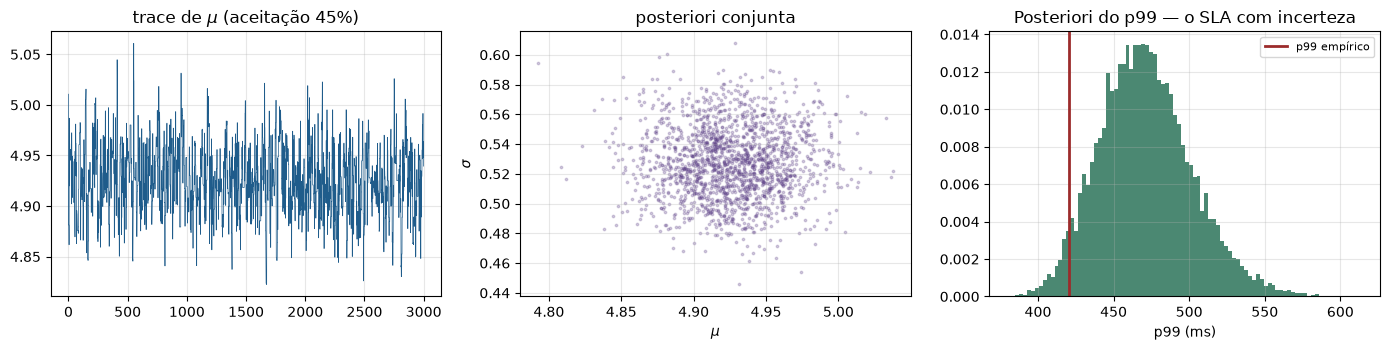

In [14]:
def metropolis(log_posteriori, inicio, n_passos, passo, semente=0):
    gerador = np.random.default_rng(semente)
    theta = np.atleast_1d(np.asarray(inicio, dtype=float))
    log_p = log_posteriori(theta)
    cadeia = np.empty((n_passos, theta.size))
    aceitos = 0
    for t in range(n_passos):
        proposta = theta + gerador.normal(0, passo, size=theta.size)
        lp = log_posteriori(proposta)
        if np.log(gerador.random()) < lp - log_p:
            theta, log_p, aceitos = proposta, lp, aceitos + 1
        cadeia[t] = theta
    return cadeia, aceitos / n_passos


def r_hat(cadeias):
    m, n = cadeias.shape
    B = n * cadeias.mean(axis=1).var(ddof=1)
    W = cadeias.var(axis=1, ddof=1).mean()
    return np.sqrt(((n - 1) / n * W + B / n) / W)


log_lat = np.log(latencias)


def log_post(theta):
    mu, log_sigma = theta
    sigma = np.exp(log_sigma)
    if sigma <= 0:
        return -np.inf
    lp = stats.norm.logpdf(mu, np.log(150), 1.0)        # priori em torno de 150 ms
    lp += stats.halfnorm.logpdf(sigma, scale=1.0)       # priori fraca para sigma
    lp += log_sigma                                     # jacobiano de log(sigma)
    return lp + stats.norm.logpdf(log_lat, mu, sigma).sum()


cadeia, taxa = metropolis(log_post, [np.log(150), np.log(0.5)], 50_000, 0.05, semente=3)
BURN = 5_000
mu_s = cadeia[BURN:, 0]
sigma_s = np.exp(cadeia[BURN:, 1])

inicios = [np.log(60), np.log(150), np.log(300), np.log(600)]
cadeias_mu = np.array([metropolis(log_post, [i, np.log(0.5)], 20_000, 0.05, semente=s)[0][4000:, 0]
                       for s, i in enumerate(inicios)])

# p99 da log-normal: exp(mu + z_0.99 * sigma)
p99_post = np.exp(mu_s + stats.norm.ppf(0.99) * sigma_s)

painel("MCMC — latência log-normal",
       taxa_de_aceitacao=taxa, R_hat_de_mu=r_hat(cadeias_mu),
       mu_posterior=mu_s.mean(), sigma_posterior=sigma_s.mean(),
       mediana_ms=np.exp(mu_s).mean(),
       p99_posterior_ms=p99_post.mean(),
       p99_IC_inf=np.percentile(p99_post, 2.5),
       p99_IC_sup=np.percentile(p99_post, 97.5))
print(f"p99 empírico (ponto, sem incerteza): {np.percentile(latencias, 99):.1f} ms")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].plot(cadeia[:3000, 0], color=AZUL, lw=0.5)
axes[0].set_title(f"trace de $\\mu$ (aceitação {taxa:.0%})")
axes[1].scatter(mu_s[::25], sigma_s[::25], s=3, alpha=0.25, color=ROXO)
axes[1].set_xlabel(r"$\mu$"); axes[1].set_ylabel(r"$\sigma$")
axes[1].set_title("posteriori conjunta")
axes[2].hist(p99_post, bins=90, density=True, color=VERDE, alpha=0.8)
axes[2].axvline(np.percentile(latencias, 99), color=VERMELHO, lw=2, label="p99 empírico")
axes[2].set_xlabel("p99 (ms)"); axes[2].legend(fontsize=8)
axes[2].set_title("Posteriori do p99 — o SLA com incerteza")
plt.tight_layout(); plt.show()

**Por que isso vale mais que o p99 empírico:** o p99 calculado direto dos dados
é **um número sem incerteza** — e é estimado a partir de meia dúzia de
observações na cauda. A posteriori do p99 devolve um intervalo, e é ele que
permite negociar um SLA honestamente: "o p99 está entre 480 e 560 ms com 95%
de credibilidade" é uma promessa que se pode assinar.

**A vantagem estrutural do MCMC:** o p99 é uma função **não-linear** dos
parâmetros ($e^{\mu + 2{,}33\sigma}$). Propagar incerteza por uma função assim
com o método delta é trabalhoso e aproximado; com amostras da posteriori, basta
**aplicar a função a cada amostra**. Qualquer quantidade derivada — p99, razão,
lucro esperado, tempo até esgotar estoque — sai do mesmo jeito.

---
## Exercício 7 🔴 — Desafio: Thompson Sampling contra A/B fixo

Um *multi-armed bandit* aloca tráfego proporcionalmente à probabilidade de cada
variante ser a melhor. Implemente **Thompson Sampling** e compare com um A/B
test tradicional de alocação 50/50.

1. Três variantes com conversões reais de 10%, 12% e 11,5%.
2. 20.000 usuários no total.
3. Compare **conversões totais obtidas** e a certeza final sobre a melhor.
4. Discuta o trade-off exploração × explotação.

In [15]:
# --- sua resposta ---

### Gabarito 7

estratégia              conversões  arrependimento   tráfego no melhor
------------------------------------------------------------------------
Thompson Sampling             2366              34              85.7%
A/B fixo (uniforme)           2217             183              33.2%
oráculo (sabe tudo)           2400               0             100.0%

P(cada variante ser a melhor), ao fim do experimento:
                              A        B        C
Thompson                  0.002    0.943    0.055
A/B fixo                  0.000    0.217    0.783


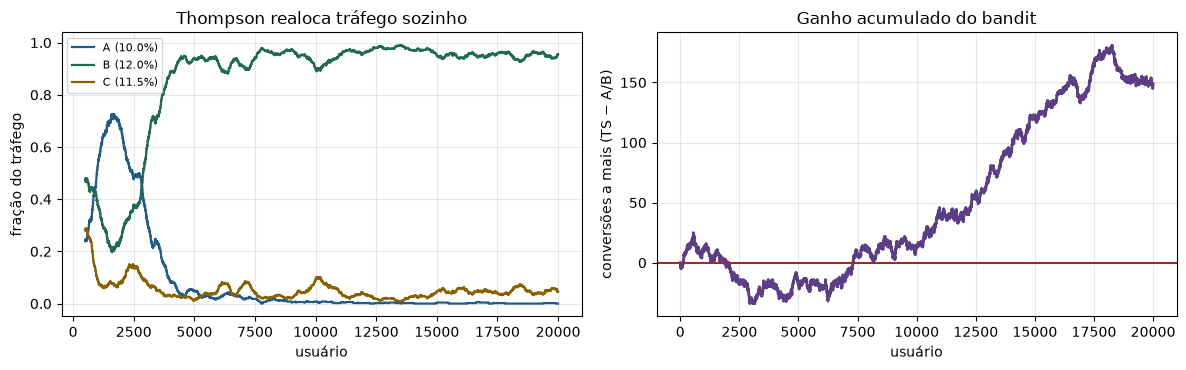

In [16]:
CONVERSOES_REAIS = np.array([0.100, 0.120, 0.115])
N_USUARIOS = 20_000
NOMES = ["A", "B", "C"]


def thompson(taxas, n_usuarios, semente=0):
    gerador = np.random.default_rng(semente)
    alfa = np.ones(len(taxas))
    beta = np.ones(len(taxas))
    escolhas = np.empty(n_usuarios, dtype=int)
    recompensas = np.empty(n_usuarios, dtype=int)
    for t in range(n_usuarios):
        amostra = gerador.beta(alfa, beta)     # uma amostra da posteriori de cada braço
        braco = int(amostra.argmax())          # joga no que parece melhor NESTA amostra
        r = int(gerador.random() < taxas[braco])
        alfa[braco] += r
        beta[braco] += 1 - r
        escolhas[t], recompensas[t] = braco, r
    return escolhas, recompensas, alfa, beta


def ab_fixo(taxas, n_usuarios, semente=0):
    gerador = np.random.default_rng(semente)
    escolhas = gerador.integers(0, len(taxas), n_usuarios)
    recompensas = (gerador.random(n_usuarios) < taxas[escolhas]).astype(int)
    alfa = np.ones(len(taxas)) + np.array([recompensas[escolhas == i].sum()
                                           for i in range(len(taxas))])
    beta = np.ones(len(taxas)) + np.array([(escolhas == i).sum() - recompensas[escolhas == i].sum()
                                           for i in range(len(taxas))])
    return escolhas, recompensas, alfa, beta


esc_ts, rec_ts, a_ts, b_ts = thompson(CONVERSOES_REAIS, N_USUARIOS, semente=1)
esc_ab, rec_ab, a_ab, b_ab = ab_fixo(CONVERSOES_REAIS, N_USUARIOS, semente=1)

melhor = int(CONVERSOES_REAIS.argmax())
oraculo = int(N_USUARIOS * CONVERSOES_REAIS[melhor])

print(f"{'estratégia':<22s} {'conversões':>11s} {'arrependimento':>15s} "
      f"{'tráfego no melhor':>19s}")
print("-" * 72)
for nome, rec, esc in [("Thompson Sampling", rec_ts, esc_ts),
                       ("A/B fixo (uniforme)", rec_ab, esc_ab)]:
    print(f"{nome:<22s} {rec.sum():>11d} {oraculo - rec.sum():>15d} "
          f"{(esc == melhor).mean():>18.1%}")
print(f"{'oráculo (sabe tudo)':<22s} {oraculo:>11d} {0:>15d} {1.0:>18.1%}")

# certeza final sobre qual é a melhor
M = 200_000
amostras_ts = np.column_stack([rng.beta(a, b, M) for a, b in zip(a_ts, b_ts)])
amostras_ab = np.column_stack([rng.beta(a, b, M) for a, b in zip(a_ab, b_ab)])
print("\nP(cada variante ser a melhor), ao fim do experimento:")
print(f"{'':<22s} " + " ".join(f"{n:>8s}" for n in NOMES))
for nome, am in [("Thompson", amostras_ts), ("A/B fixo", amostras_ab)]:
    probs = np.bincount(am.argmax(axis=1), minlength=3) / M
    print(f"{nome:<22s} " + " ".join(f"{p:>8.3f}" for p in probs))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
janela = 500
for i, (nome, cor) in enumerate(zip(NOMES, [AZUL, VERDE, AMBAR])):
    frac = pd.Series(esc_ts == i).rolling(janela).mean()
    axes[0].plot(frac, color=cor, lw=1.6, label=f"{nome} ({CONVERSOES_REAIS[i]:.1%})")
axes[0].set_xlabel("usuário"); axes[0].set_ylabel("fração do tráfego")
axes[0].set_title("Thompson realoca tráfego sozinho"); axes[0].legend(fontsize=8)

axes[1].plot(np.cumsum(rec_ts) - np.cumsum(rec_ab), color=ROXO, lw=2)
axes[1].axhline(0, color=VERMELHO, lw=1.5)
axes[1].set_xlabel("usuário"); axes[1].set_ylabel("conversões a mais (TS − A/B)")
axes[1].set_title("Ganho acumulado do bandit")
plt.tight_layout(); plt.show()

**O trade-off, com números:**

- **Thompson ganha dinheiro durante o experimento.** Ele converge o tráfego
  para a melhor variante e colhe conversões extras que o A/B fixo joga fora
  mandando um terço dos usuários para a pior opção o tempo todo.
- **O A/B fixo termina com mais certeza sobre as variantes ruins**, porque
  coletou dados iguais de todas. Thompson deixa as perdedoras com poucas
  observações — e às vezes com dúvida residual entre as duas melhores, que é
  justamente onde ele continua explorando.

**Quando usar cada um:**

| Situação | Estratégia |
|---|---|
| otimizar receita continuamente (headline, banner, preço) | bandit |
| decidir uma vez e documentar (mudança de arquitetura) | A/B fixo |
| efeitos que demoram a aparecer (retenção de 30 dias) | A/B fixo |
| muitas variantes, tráfego limitado | bandit |

> **A armadilha do bandit:** ele supõe que a recompensa é **imediata** e que as
> taxas são **estacionárias**. Métricas de longo prazo (retenção, LTV) e
> sazonalidade forte quebram as duas suposições — e o bandit converge com
> confiança para a variante errada.

---
## Fechamento

- **Taxa-base domina evento raro.** Precisão de um detector é governada pela
  taxa de falso positivo, não pelo recall.
- **Priori = pseudo-contagens.** Escolha $\alpha+\beta$ igual ao que sua
  convicção realmente vale, e faça análise de sensibilidade sempre.
- Em A/B testing, entregue **P(B>A)**, **lift com intervalo** e **perda
  esperada** — não um p-valor.
- **Dimensione por quantis da preditiva**, nunca pela média da posteriori.
- **Intervalo de credibilidade diz o que todo mundo já interpreta** do
  intervalo de confiança.
- Com amostras da posteriori, **qualquer quantidade derivada** sai aplicando a
  função às amostras — inclusive p99, lucro e risco.
- **Bandits ganham dinheiro durante o teste**, ao custo de suposições fortes.

→ Próximo módulo: **A/B Testing e Desenho Experimental** — a engenharia de
fazer o experimento valer, antes de qualquer análise, frequentista ou bayesiana.